In [2]:
# 06 - Model Preparation
# Takes the engineered feature table from 05_Feature_Engineering.ipynb and
# prepares it for modeling: encode categorical variables, train/test split,
# handle class imbalance.
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight

plt.rcParams['figure.dpi'] = 100

feature_table = pd.read_csv('data/processed/features/Engineered_Features.csv')
print(f"Loaded: {feature_table.shape}")
feature_table.head()


Loaded: (186, 15)


,Respondent_ID,Age_Group_Code,Gender,Occupation,Residence_Type,Usage_Frequency_Code,Satisfaction_Code,Num_Tools_Known,Num_Usage_Purposes,Num_Usage_Contexts,Num_Concerns,Is_Heavy_User,Has_Multiple_Concerns,Knows_Multiple_Tools,Most_Used_Tool
0,R001,2,Female,Student,Semi - Urban,6.0,4.0,3,7,1,5,1,1,1,Claude
1,R002,2,Female,Student,Urban,6.0,4.0,3,4,3,4,1,1,1,ChatGPT
2,R003,2,Male,Student,Urban,6.0,5.0,5,4,4,1,1,0,1,Claude
3,R004,2,Male,Student,Rural,4.0,4.0,4,3,2,3,0,1,1,Claude
4,R005,2,Male,Student,Urban,4.0,4.0,2,4,2,1,0,0,1,ChatGPT


In [3]:
# Encode categorical variables (one-hot) 
categorical_cols = ['Gender', 'Occupation', 'Residence_Type']
non_feature_cols = ['Respondent_ID', 'Most_Used_Tool']
feature_cols = [c for c in feature_table.columns if c not in non_feature_cols]

X = pd.get_dummies(feature_table[feature_cols], columns=categorical_cols, drop_first=True)
y = feature_table['Most_Used_Tool']
print(f"Feature matrix shape: {X.shape}")
X.columns.tolist()


Feature matrix shape: (186, 26)


['Age_Group_Code',
 'Usage_Frequency_Code',
 'Satisfaction_Code',
 'Num_Tools_Known',
 'Num_Usage_Purposes',
 'Num_Usage_Contexts',
 'Num_Concerns',
 'Is_Heavy_User',
 'Has_Multiple_Concerns',
 'Knows_Multiple_Tools',
 'Gender_Male',
 'Occupation_Dental Surgeon',
 'Occupation_Doctor',
 'Occupation_Engineer',
 'Occupation_Freelancer',
 'Occupation_Government Employee',
 'Occupation_IT professional',
 'Occupation_Ophthalmic Assistant',
 'Occupation_Private-sector Employee',
 'Occupation_Researcher',
 'Occupation_Student',
 'Occupation_Student & Working Professional',
 'Occupation_Teacher',
 'Occupation_Unemployed',
 'Residence_Type_Semi - Urban',
 'Residence_Type_Urban']

In [4]:
# Train/test split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print()
print("Train class distribution:")
print(y_train.value_counts())


Train: (139, 26), Test: (47, 26)

Train class distribution:
Most_Used_Tool
ChatGPT    76
Claude     42
Gemini     21
Name: count, dtype: int64


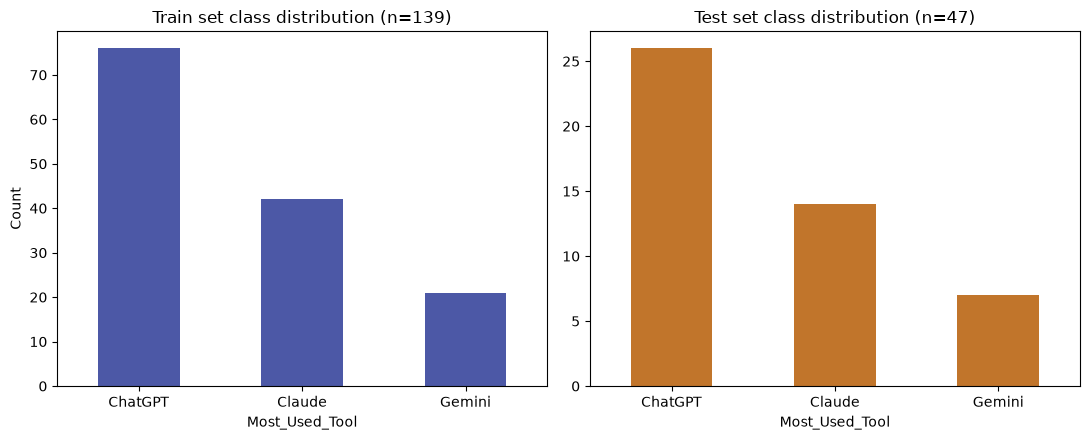

In [5]:
#  Diagram: class distribution, train vs test 
# Confirms the stratified split kept the same class proportions in both sets.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
y_train.value_counts().plot(kind='bar', ax=axes[0], color='#4C58A6')
axes[0].set_title(f'Train set class distribution (n={len(y_train)})')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
y_test.value_counts().plot(kind='bar', ax=axes[1], color='#C1752B')
axes[1].set_title(f'Test set class distribution (n={len(y_test)})')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


In [6]:
# Handle class imbalance 
# ChatGPT dominates the sample, so a naively trained model would just learn to
# always predict it. We compute balanced sample weights so every class
# contributes equally during training, without dropping or duplicating rows.
sample_weight_train = compute_sample_weight(class_weight='balanced', y=y_train)
weight_check = pd.DataFrame({'Most_Used_Tool': y_train.values, 'sample_weight': sample_weight_train})
weight_summary = weight_check.groupby('Most_Used_Tool')['sample_weight'].first()
print(weight_summary)


Most_Used_Tool
ChatGPT    0.609649
Claude     1.103175
Gemini     2.206349
Name: sample_weight, dtype: float64


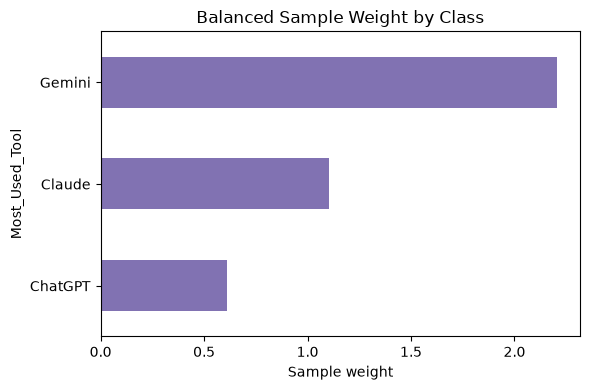

In [7]:
# Diagram: sample weight by class 
# The rarer a class, the higher its weight -- this is what makes "balanced"
# weighting work: Gemini (fewest respondents) gets weighted highest.
plt.figure(figsize=(6, 4))
weight_summary.sort_values().plot(kind='barh', color='#8172B2')
plt.xlabel('Sample weight')
plt.title('Balanced Sample Weight by Class')
plt.tight_layout()
plt.show()


In [8]:
#  Save prepared data 
out_dir = 'data/processed/ml_ready'
os.makedirs(out_dir, exist_ok=True)
X_train.to_csv(f'{out_dir}/X_train.csv', index=False)
X_test.to_csv(f'{out_dir}/X_test.csv', index=False)
y_train.to_csv(f'{out_dir}/y_train.csv', index=False)
y_test.to_csv(f'{out_dir}/y_test.csv', index=False)
pd.Series(sample_weight_train, name='sample_weight').to_csv(f'{out_dir}/sample_weight_train.csv', index=False)
print(f"Saved train/test files to {out_dir}/")


Saved train/test files to data/processed/ml_ready/
